# ABテスト入門（２）（吉村）

R で演習するための Google Colab notebook です。Googleアカウントにログインした状態でブラウザから利用できます。

**コードは自由に編集して構いません。**

コメント加筆や修正しながらの利用を奨めます。同時に閲覧する他の利用者とも編集内容は共有されません。
誤ってコード等を消した場合、再び本ページにアクセスし直せばデフォルトから再開できます。
Google driveに本ページ（ipynbファイル）を保存すると編集内容を引き継ぐことができます。

ランタイムは R、ハードウェアは CPU を前提とします。
問い合わせ先：yoshimura at cc.kyoto-su.ac.jp

# コード演習で学ぶこと


*   前回の復習
*   無作為抽出の理解
*   標本平均の挙動
*   標本平均の標本分布（モンテカルロシミュレーション）
*   検定のやり方
*   検定の過誤の計算（有意水準の理解）


# メインコード

[1] 43.73546

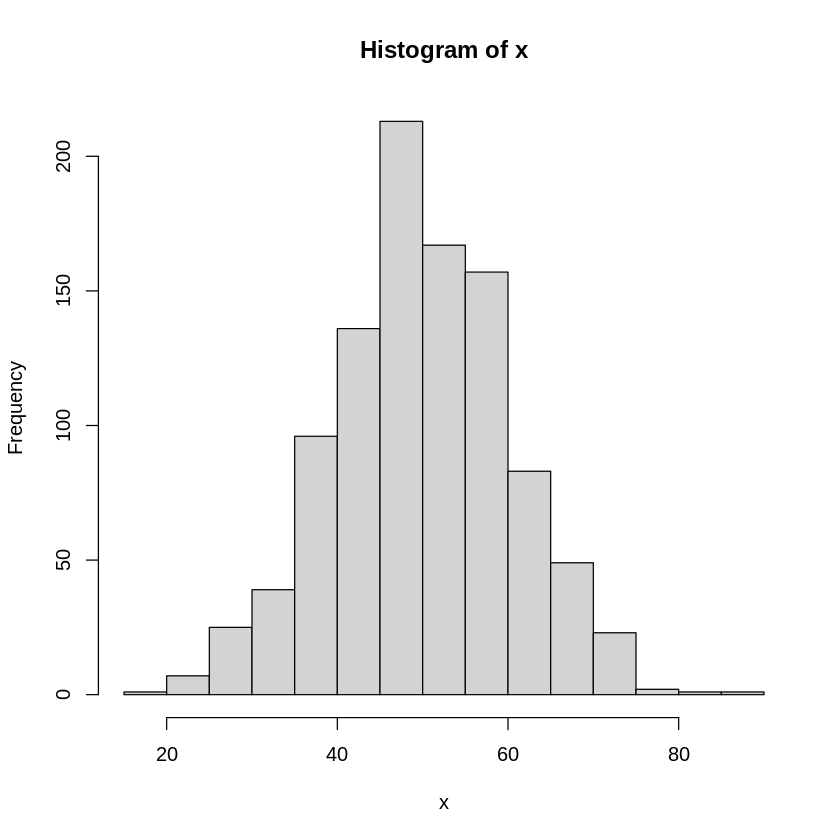

In [7]:
# 復習（乱数生成、可視化）
set.seed(1)
rnorm(1, mean=50, sd=10)
x <- rnorm(1000, mean=50, sd=10)
hist(x)

In [8]:
# 復習（乱数のシード）
set.seed(1)
rnorm(1)

set.seed(2)
rnorm(1)

set.seed(1)
rnorm(1)

set.seed(3)
rnorm(10)

set.seed(4)
rnorm(10)

set.seed(3)
rnorm(10)

[1] -0.6264538

[1] -0.8969145

[1] -0.6264538

[1] -0.96193342 -0.29252572  0.25878822 -1.15213189  0.19578283  0.03012394
 [7]  0.08541773  1.11661021 -1.21885742  1.26736872

[1]  0.2167549 -0.5424926  0.8911446  0.5959806  1.6356180  0.6892754
 [7] -1.2812466 -0.2131445  1.8965399  1.7768632

[1] -0.96193342 -0.29252572  0.25878822 -1.15213189  0.19578283  0.03012394
 [7]  0.08541773  1.11661021 -1.21885742  1.26736872

mean= -0.009886723 sd= 1.035367 


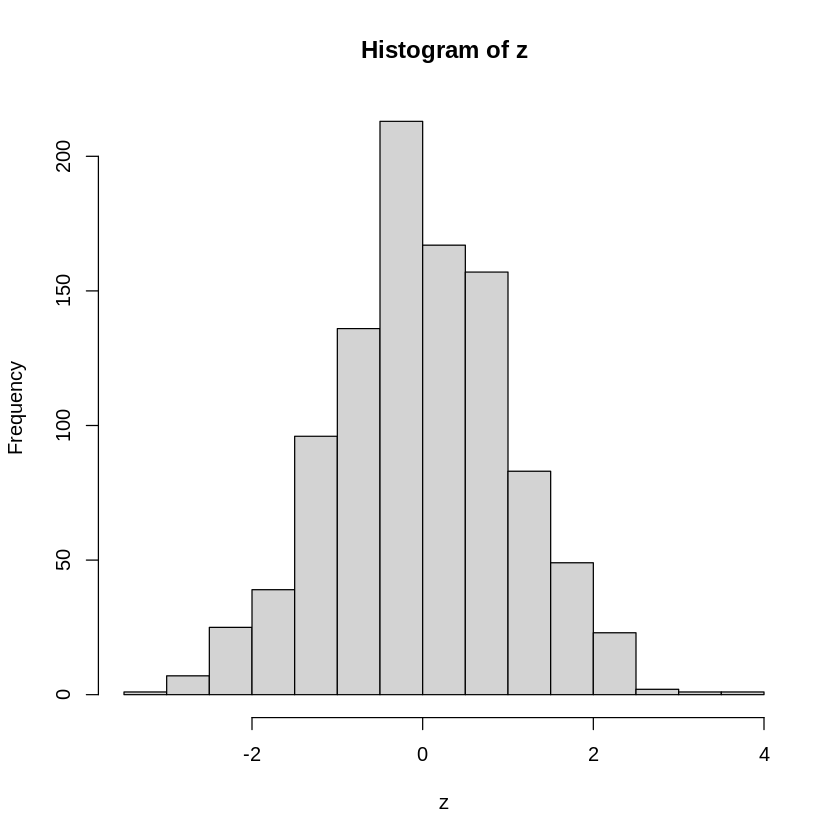

In [9]:
# 復習（標準化）
z <- (x - 50)/10
hist(z)
cat("mean=",mean(z),"sd=",sd(z),"\n")

In [10]:
# 無作為抽出
set.seed(NULL)
pop <- rnorm(1e4, mean=50, sd=10)                   # 母集団分布は正規分布からの10000のドローとする（※ 現実にはこの母集団を観測できないことが多い）

sample(pop, 10)                                     # 母集団から、大きさ10の無作為標本を取得：sample()

mean(sample(pop, 10))                               # 無作為標本の標本平均

replicate(5, mean(sample(pop, 10)))                 # 無作為標本およびその標本平均を、5個ずつ複製する：replicate()

[1] 51.38070 71.00663 53.18365 43.87148 50.48919 31.05612 43.70864 61.69599
 [9] 64.45837 42.40795

[1] 44.72443

[1] 54.63896 48.74498 48.36419 50.88034 58.56666

In [24]:
# 手入力で次のことをやってみましょう
# １．popを使って、大きさ100の標本をとってみましょう
# ２．その標本平均を計算しましょう
# ３．replicate()を使って、popからの大きさ100の標本の標本平均を10個複製してみましょう
x_1 <- sample(pop, 100)
mean(x_1)

replicate(10, mean(sample(pop, 100)))

[1] 49.45907

[1] 49.00060 50.46158 48.74155 50.20685 51.22846 50.40733 49.79584 50.75027
 [9] 49.01254 49.38807

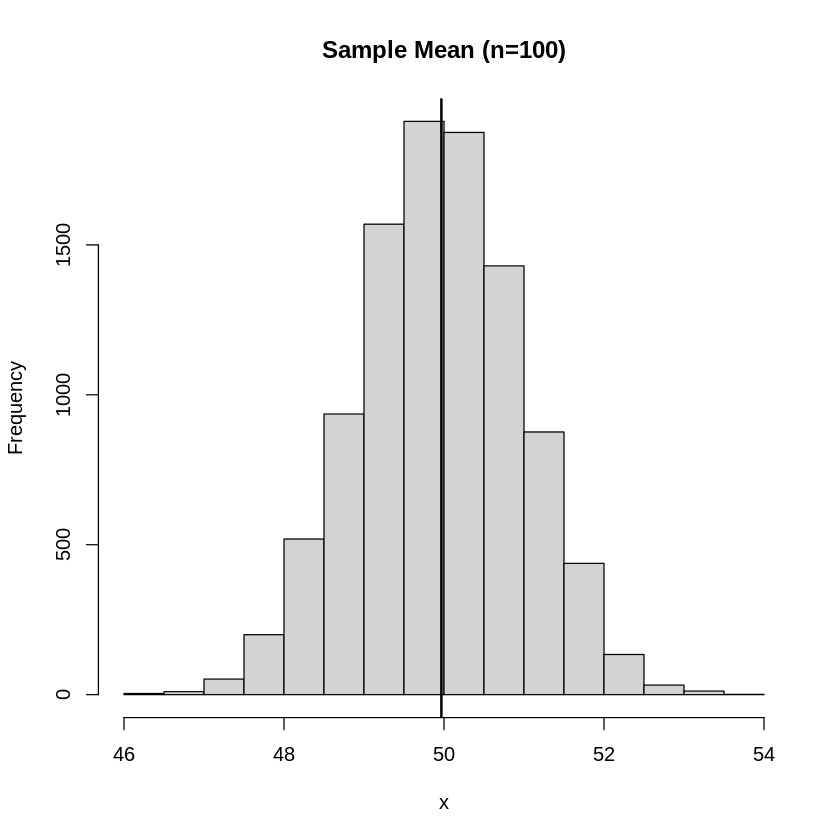

In [25]:
# 仮想的な無作為標本を10000個取得して標本平均のヒストグラムを作る

m <- replicate(10000, mean(sample(pop, 100)))      # 大きさ100の無作為標本の標本平均を10000個取得（多いほど良い）
hist(m, main="Sample Mean (n=100)", xlab="x")      # ヒストグラム（これが標本分布の可視化）
abline(v=mean(pop), lwd=2)                         # 母集団分布の平均を重ねて表示

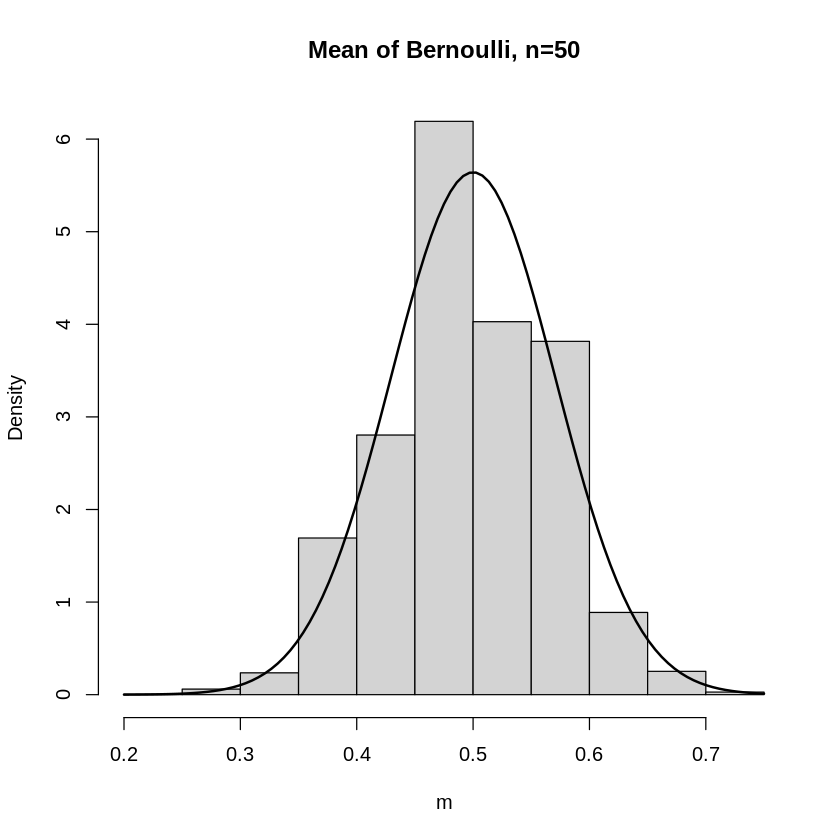

In [12]:
# 標本平均の標本分布
set.seed(NULL)
p <- 0.5
n <- 50
m <- replicate(5000, mean(rbinom(n, 1, p)))         # ベルヌーイ分布の標本平均を5000個取得
hist(m, prob=TRUE, main="Mean of Bernoulli, n=50")
curve(dnorm(x, mean=p, sd=sqrt(p*(1-p)/n)), add=TRUE, lwd=2)

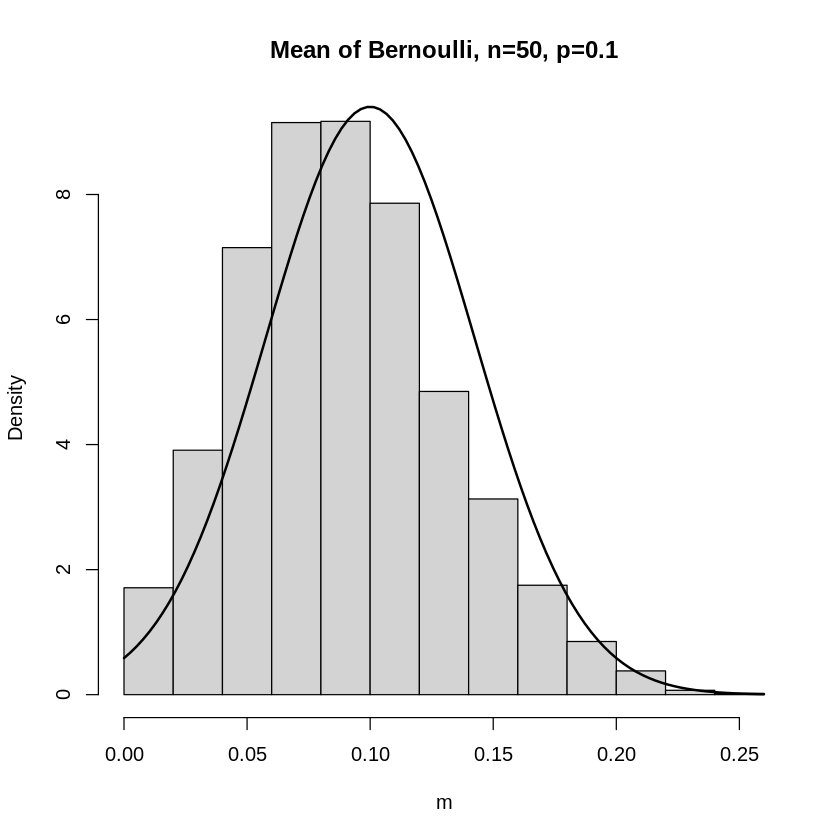

In [26]:
# 手入力で次のことをやってみましょう
# 上の例で、p = 0.1でやり直したときのヒストグラムを作ってみましょう

set.seed(NULL)
p <- 0.1
n <- 50

m <- replicate(5000, mean(rbinom(n, 1, p)))

hist(m, prob = TRUE, main = "Mean of Bernoulli, n=50, p=0.1")

curve(dnorm(x, mean = p, sd = sqrt(p * (1 - p) / n)),
      add = TRUE, lwd = 2)


In [27]:
# Z検定（分散既知、両側、alpha=0.05）
set.seed(NULL)
alpha <- 0.05                                # 有意水準を設定（5%）

n <- 100                                     # 大きさ100
sigma <- 1                                   # 母分散を既知として1に設定
x <- rnorm(n, mean=0.2, sd=sigma)            # 正規母集団（期待値0.2）から無作為標本を取得

mu0 <- 0                                     # 帰無仮説の値を設定(mu=0)
z <- (mean(x) - mu0) / (sigma / sqrt(n))     # 帰無仮説の値を代入しつつ検定統計値を計算

crit <- qnorm(1 - alpha / 2)                 # 標準正規分布の上側97.5%点: qnorm()

cat("mean=", mean(x), "z=", z, " | 検定結果：", ifelse(abs(z) > crit, "H0を棄却", "H0を採択"), "\n")

# 実行するたびに結果が分かれうることを確認しましょう（絶妙な設定になっています）

mean= 0.192121 z= 1.92121  | 検定結果： H0を採択 


1.644854 1.959964 2.575829

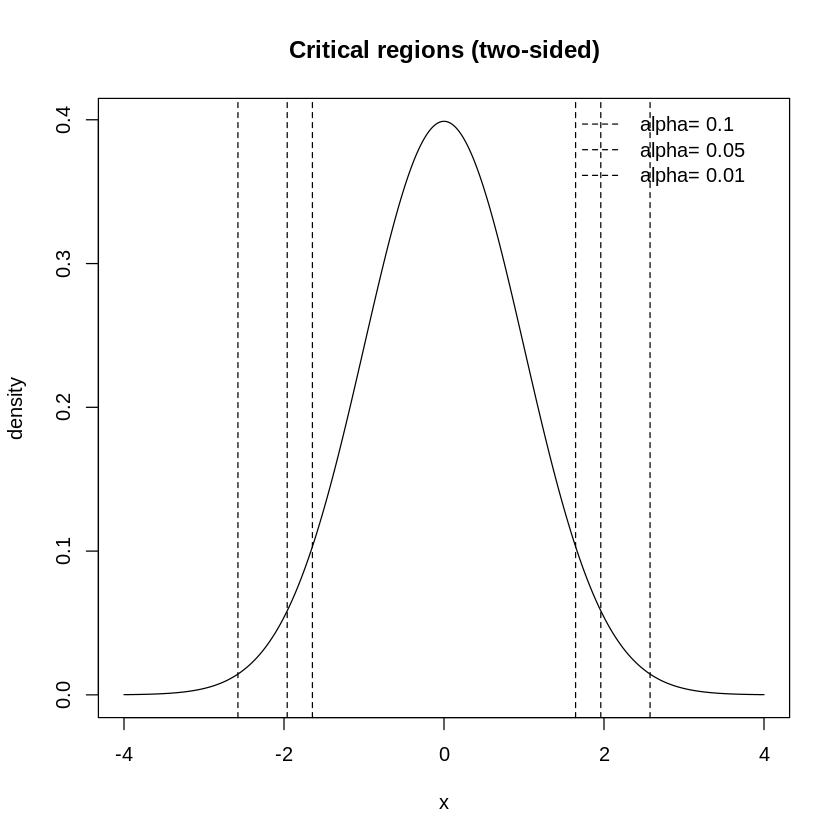

In [28]:
# 有意水準と棄却域の可視化（標準正規）※参考資料
x <- seq(-4, 4, length=400)  # グリッド用意
plot(x, dnorm(x), type="l", main="Critical regions (two-sided)", ylab="density") # 標準正規分布の密度を可視化

a <- c(0.10, 0.05, 0.01)     # 有意水準を３パターン
crit <- qnorm(1 - a/2)       # 標準正規に基づく棄却限界を用意

abline(v=c(-crit, crit), lty=2) # タテ線で棄却限界を可視化
legend("topright", legend=paste("alpha=", a), lty=2, bty="n") # 凡例をつける
cat(crit)

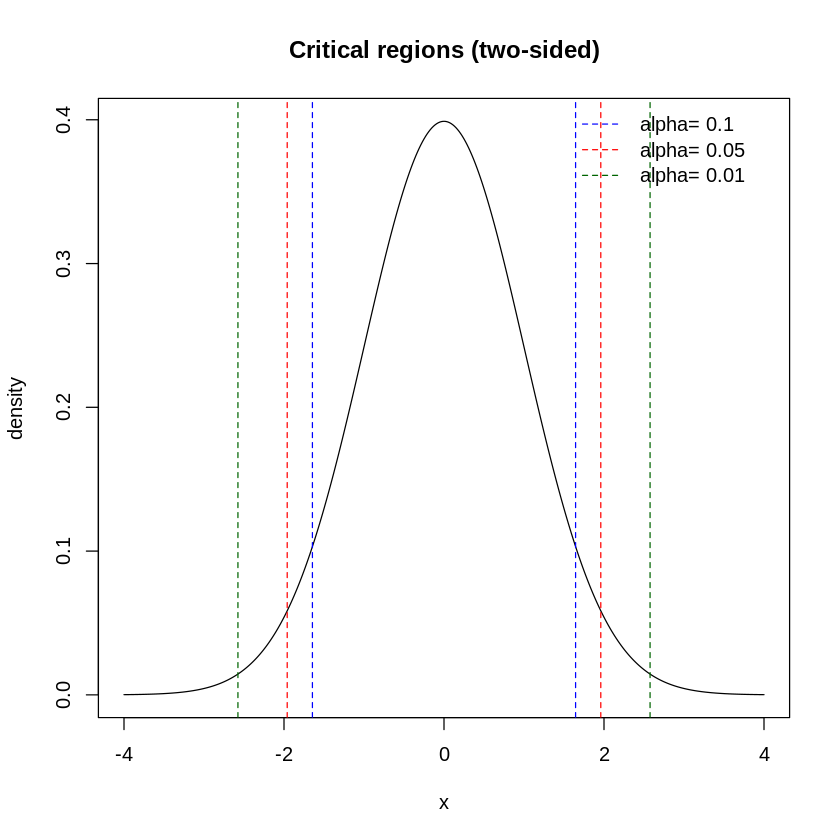

In [29]:
# *カラーバージョン（演習対象外）※参考資料
plot(x, dnorm(x), type="l", main="Critical regions (two-sided)", ylab="density")
cols <- c("blue", "red", "darkgreen")
for (i in 1:length(crit)) {
  abline(v=c(-crit[i], crit[i]), lty=2, col=cols[i])
  }
legend("topright", legend=paste("alpha=", a), lty=2, col=cols, bty="n")

In [30]:
# Monte Carlo シミュレーション：第一種の過誤（Z検定, 分散既知, 両側）
# 第一種の過誤：仮説が正しいにも関わらず「仮説は間違いである」と判定する誤りのこと

set.seed(11)
M <- 1000 # 繰り返し数

alpha <- 0.05
n <- 10
sigma <- 1

mu0 <- 0
z <- replicate(M, { x <- rnorm(n, mu0, sigma); (mean(x) - mu0) / (sigma/sqrt(n)) }) # 帰無仮説が正しいとして

print(z)
crit <- qnorm(1 - alpha/2)
cat("alpha =", alpha, "  Type-I error=", mean(abs(z) > crit), "  ( M =", M, ")\n")

   [1] -0.7275216430 -1.4835297418 -0.9063213894 -0.9253469052 -0.4471395264
   [6]  0.8769347231 -0.0215686655  0.0535837567 -0.8711879917  0.5462504671
  [11]  0.2121751823 -0.0092735651  2.2872984847 -1.6746781966 -0.0746262973
  [16]  0.7201170594 -0.9327392331  1.3531051566  0.3340357219  1.6575893403
  [21] -0.1646528770  0.0013779851 -0.6817562296 -0.5507536461  0.8356100268
  [26]  0.4516467986 -1.3674650687 -0.1888282395 -0.4374623454  0.2381016072
  [31]  1.0239322153 -0.3740105323 -0.4219713472 -2.0157929428 -0.9589973956
  [36]  0.5337452750 -0.2523067227 -0.4405904289  1.7006887619  0.9275891734
  [41]  0.0084709769  0.3640702702 -0.4693221867 -0.2908698008  1.2717638876
  [46] -0.4860298099 -1.1621654033  0.3576836738  1.1622375354  1.0014153070
  [51] -0.4843703068  1.0770646414  1.2442988390 -0.0174136799  0.9981455315
  [56] -0.2050204604  0.0315672363 -1.3839503959 -0.1865350611  1.8282621296
  [61] -0.1202427336 -0.5000663542  0.8124186012  0.7019369854  0.9228697899

In [31]:
# 上記のセクションにおける繰り返し数を、10000回にして実行してみましょう
# 第一種の過誤（typeI error）はどうなったでしょうか？
set.seed(11)
M <- 10000
alpha <- 0.05
n <- 10
sigma <- 1
mu0 <- 0

z <- replicate(M, {
  x <- rnorm(n, mu0, sigma)
  (mean(x) - mu0) / (sigma / sqrt(n))
})

crit <- qnorm(1 - alpha/2)

mean(abs(z) > crit)


[1] 0.0439

In [32]:
# Monte Carlo シミュレーションをfor文で書いてみる ※参考資料
set.seed(11)
M <- 1000                                  # 繰り返し数

cnt <- 0                                   # カウンター（仮想的繰り返し標本において、棄却した回数をカウントしたい）

for (i in 1:M) {
  x <- rnorm(n, mu0, sigma)                # xに無作為標本（帰無仮説が正しいとした下での）
  z <- (mean(x) - mu0) / (sigma / sqrt(n)) # 帰無仮説に基づくz値を計算
  if (abs(z) > crit) cnt <- cnt + 1        # 棄却したらカウントを１増やす
  }

cat("alpha =", alpha, "  Type-I =", cnt/M, "  ( M =", M, ")\n")

alpha = 0.05   Type-I = 0.039   ( M = 1000 )


In [33]:
# 手入力で次のことをやってみましょう
# 上のfor文を用いた例でやったことを、手入力で復元してください
# その上で、sigma=2の場合にはどうなるか確認してください
set.seed(11)

M <- 1000
alpha <- 0.05
n <- 10
sigma <- 1
mu0 <- 0

cnt <- 0

for (i in 1:M) {
  x <- rnorm(n, mu0, sigma)
  z <- (mean(x) - mu0) / (sigma / sqrt(n))
  if (abs(z) > qnorm(1 - alpha/2)) {
    cnt <- cnt + 1
  }
}

cat("sigma =", sigma,
    ", Type-I error =", cnt/M,
    "(M =", M, ")\n")




sigma = 1 , Type-I error = 0.039 (M = 1000 )


In [34]:
# p値による仮説検定 ※参考資料
# p値：検定統計量が実際の統計値より（絶対値で）極端な値をとる確率のこと

set.seed(3)

x <- rnorm(40, mean=1, sd=2)
sigma <- 2

mu0 <- 0 # H_0
z <- (mean(x) - mu0) / (sigma / sqrt(length(x))) # z値

p <- 2 * (1 - pnorm(abs(z))) # p値

cat("mean=", mean(x), " z=", z, " p=", p, " -> ", ifelse(p < 0.05, "H0を棄却", "H0を採択"), "\n")

mean= 0.8863292  z= 2.802819  p= 0.005065809  ->  H0を棄却 


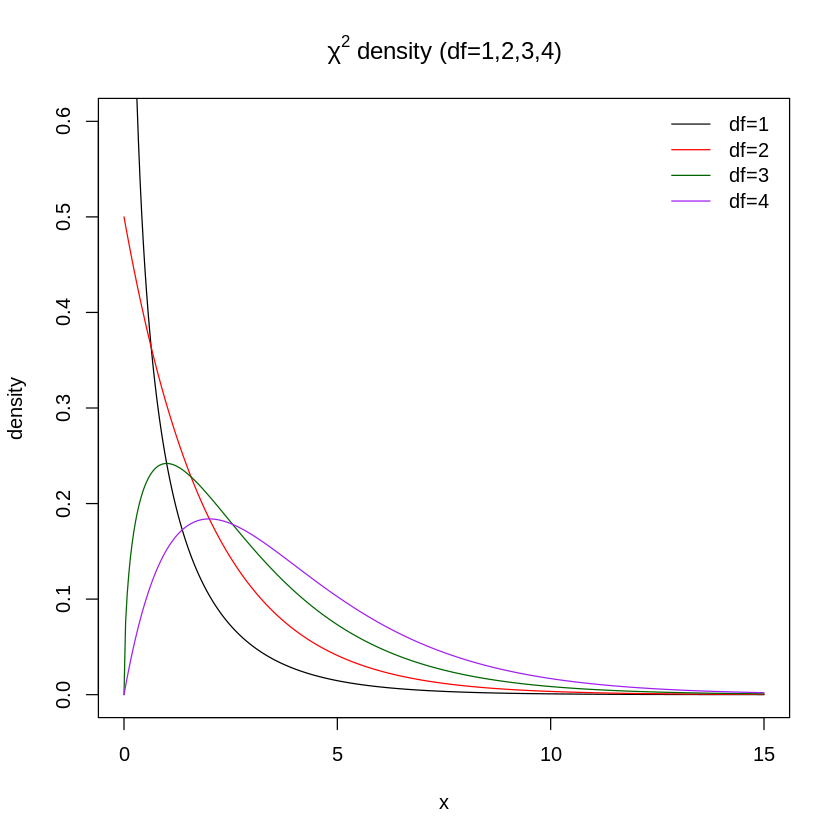

In [35]:
# Chi^2 分布（df = 1, 2, 3, 4）※参考資料
x <- seq(0, 15, length = 400)
plot(x, dchisq(x, df = 1), type = "l", ylab = "density", main = expression(chi^2*" density (df=1,2,3,4)"), ylim=c(0, 0.6))
lines(x, dchisq(x, df = 2), col = "red")
lines(x, dchisq(x, df = 3), col = "darkgreen"); lines(x, dchisq(x, df = 4), col = "purple")
legend("topright", legend = c("df=1", "df=2", "df=3", "df=4"), col = c("black", "red", "darkgreen", "purple"), lty = 1, bty = "n")

# 演習